## **DATA ANALYSIS PYTHON PROJECT - BLINKIT ANALYSIS**

### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **Import Raw Data**

In [2]:
df = pd.read_csv("blinkit_data.csv")

In [3]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [4]:
df.tail()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


### **Data Cleaning**

In [6]:
print (df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [7]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF': 'Low Fat','low fat': 'Low Fat','reg': 'Regular'})

In [8]:
print (df['Item Fat Content'].unique())

['Regular' 'Low Fat']


### **BUSINESS REQUIREMENTS**

### **KPI's REQUIREMENTS**

In [9]:
#TOTAL SALES

In [10]:
total_sales = df['Sales'].sum()
print(f"Total Sales: ${total_sales:,.1f}")

Total Sales: $1,201,681.5


In [11]:
#AVERAGE SALES

In [12]:
average_sales = df['Sales'].mean()
print(f"Average Sales: ${average_sales:,.0f}")

Average Sales: $141


In [13]:
#NO OF ITEMS SOLD

In [14]:
no_of_items_sold = df['Sales'].count()
print(f"No Of Item Sold: {no_of_items_sold: ,.0f}")

No Of Item Sold:  8,523


In [15]:
# AVERAGE RATINGS

In [16]:
average_rating = df['Rating'].mean()
print(f"Average_Ratings: {average_rating: ,.1f}")

Average_Ratings:  4.0


### **CHARTS REQUIREMENTS**

#### **Total Sales by Fat Content**

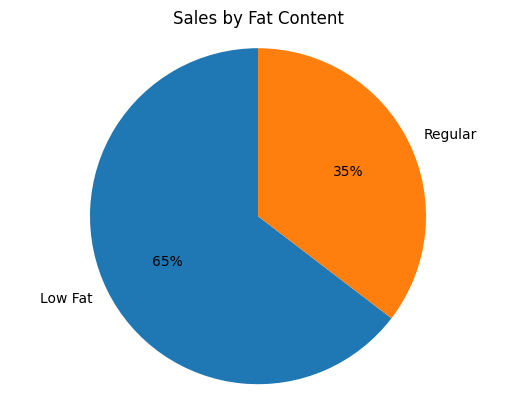

In [19]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()

plt.pie(sales_by_fat, labels = sales_by_fat.index,
                        autopct = '%.0f%%',
                        startangle = 90)
plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()

## **Total Sales by Item Type**

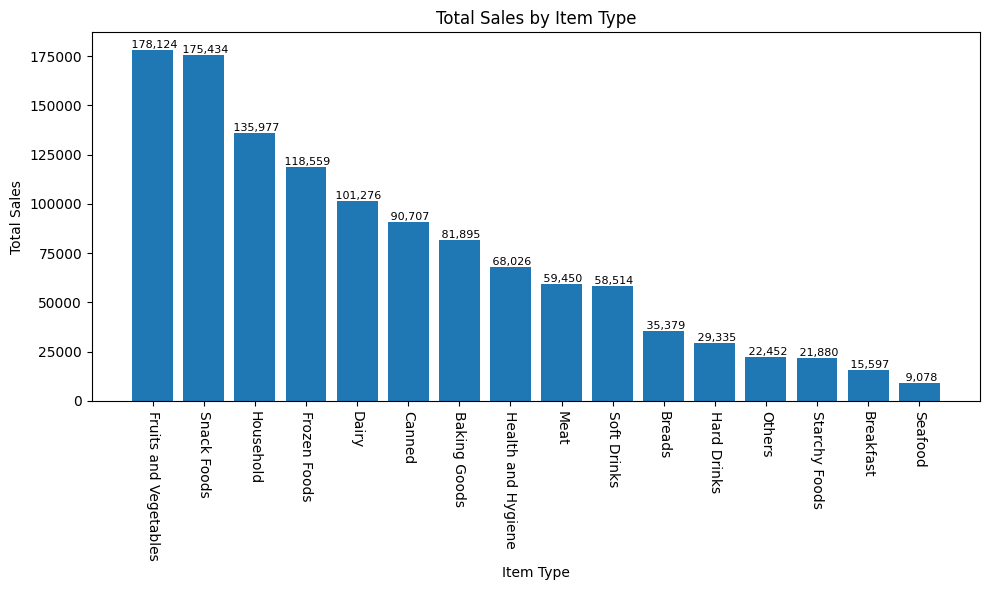

In [18]:
sales_by_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)

plt.xticks(rotation= -90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height(): ,.0f}', ha= 'center', va= 'bottom', fontsize=8)

plt.tight_layout()
plt.show()

### **Fat Content by Outlet for Total Sales**

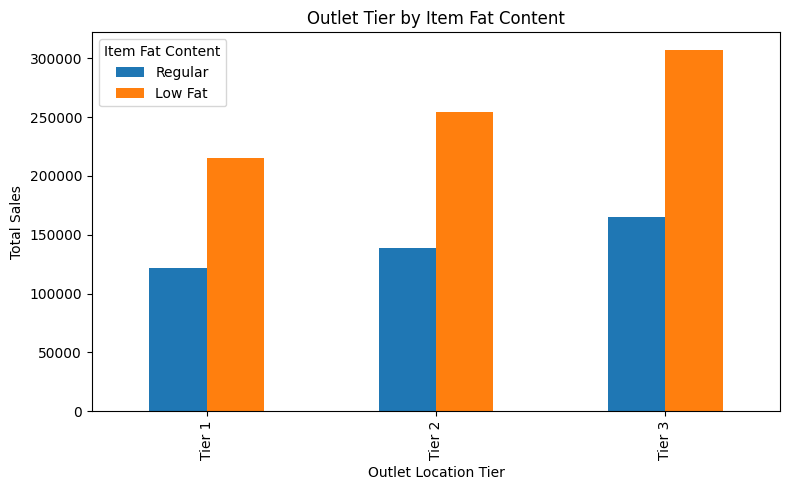

In [20]:
grouped = df.groupby (['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular', 'Low Fat']]

ax = grouped.plot(kind= 'bar', figsize= (8,5), title= 'Outlet Tier by Item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title= 'Item Fat Content')
plt.tight_layout()
plt.show()

### **Total Sales by Outlet Establishment**

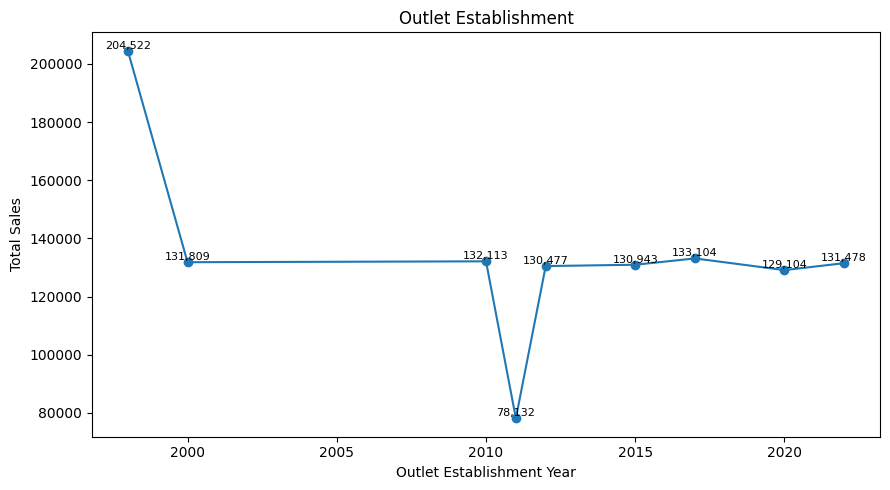

In [32]:
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(9,5))
plt.plot(sales_by_year.index, sales_by_year.values, marker= 'o', linestyle='-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x,y,f'{y:,.0f}', ha='center', va='bottom', fontsize= 8)

plt.tight_layout()
plt.show()

### **Sales by Outlet Size**

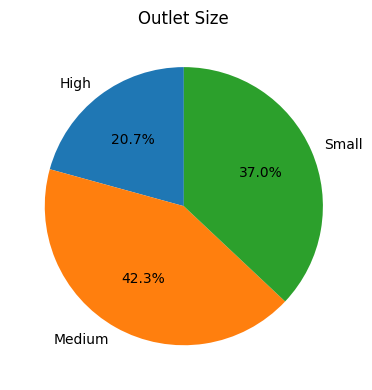

In [33]:
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize= (4,4))
plt.pie(sales_by_size, labels=sales_by_size.index, autopct= '%1.1f%%', startangle=90)
plt.title('Outlet Size')
plt.tight_layout()
plt.show()

### **Sales by Outlet Location**

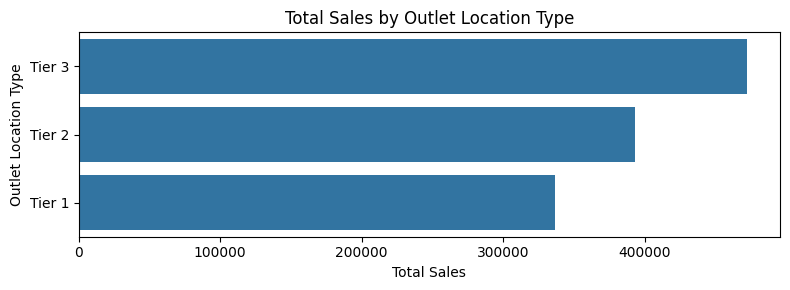

In [34]:
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
sales_by_location = sales_by_location.sort_values('Sales',ascending=False)

plt.figure(figsize=(8,3))
ax = sns.barplot(x='Sales', y= 'Outlet Location Type',data=sales_by_location)

plt.title('Total Sales by Outlet Location Type')
plt.xlabel('Total Sales')
plt.ylabel('Outlet Location Type')

plt.tight_layout()
plt.show()